# Full Fine-Tuning Evaluation Report

## Introduction

### Objectives
This report provides a comprehensive evaluation of **Full Fine-Tuning** for clinical text span extraction. This complements the LoRA evaluation by showing the full parameter update approach. The evaluation is designed for **AI master's students and professors** seeking to understand:

1. **Full Fine-Tuning behavior** vs Parameter-Efficient Fine-Tuning (LoRA)
2. **Training dynamics** with lower learning rates (1-2e-05 vs 2e-04 for LoRA)
3. **Resource requirements** - GPU VRAM usage tracking
4. **Performance outcomes** using token-level accuracy metrics

### Key Differences from LoRA
- **All parameters updated** (vs LoRA's low-rank adapters)
- **10x lower learning rate** (1-2e-05 vs 2e-04)
- **Higher memory footprint** (tracked via GPU VRAM metrics)
- **3 models evaluated** (LFM2.5-1.2B, Qwen3-1.7B, Qwen3-8B - no Llama3)
- **Token accuracy metric** (vs character F1 in LoRA evaluation)

### Dataset Context
The NBME (National Board of Medical Examiners) Clinical Patient Notes dataset requires extracting specific clinical features as text spans from patient notes.

## 1. Data Inventory & Sources

### Available Data Sources
This evaluation leverages three primary data sources:

#### 1.1 training_metrics.json (Per Model)
**Static Metadata:**
- `model_id`, `finetune_type`: Model identification and training type ("full")
- `train_samples`, `val_samples`: Dataset sizes (34737 train, 9162 val)
- `learning_rate`: 1-2e-05 (10x lower than LoRA's 2e-04)
- `training_loss`: Final training loss after 3 epochs

#### 1.2 training_timeline.csv (Per Model)
**High-Resolution Temporal Data:**
- `step`, `epoch`: Training progress (6516 steps, 3 epochs)
- `loss`, `eval_loss`: Training and validation loss (every 50 steps)
- `learning_rate`: LR at each step
- `grad_norm`: Gradient norm for stability monitoring
- `mean_token_accuracy`, `eval_mean_token_accuracy`: Token-level accuracy
- `entropy`, `eval_entropy`: Model confidence metrics
- `gpu_vram_used_gb`, `gpu_vram_reserved_gb`: **VRAM tracking (unique to Full FT)**
- `eval_runtime_s`, `eval_samples_per_second`: Computational efficiency

#### 1.3 trainer_state.json (Per Model)
**Log History:**
- Complete training log with 14 eval steps (every 500 steps)
- `best_global_step`: null (no best checkpoint tracking)
- Eval metrics: `eval_loss`, `eval_mean_token_accuracy`, `eval_entropy`

### Data Classification
| Category | Fields | Temporal/Static |
|----------|--------|------------------|
| **Optimization Dynamics** | `loss`, `grad_norm`, `learning_rate`, `epoch`, `step` | Temporal |
| **Evaluation Metrics** | `eval_loss`, `eval_mean_token_accuracy`, `entropy` | Temporal |
| **Resource Usage** | `gpu_vram_used_gb`, `gpu_vram_reserved_gb` | Temporal |
| **System Metadata** | `model_id`, sample counts, learning_rate | Static |

### Identified Gaps and Limitations
1. **No char_f1 metric** - Uses token accuracy instead of character-level F1
2. **No tfevents files** - Must rely on CSV timeline for high-resolution data
3. **No Llama3 model** - Only 3 models vs 4 in LoRA evaluation
4. **Limited eval frequency** - 14 eval steps vs 144 in LoRA (eval every 500 vs 50 steps)

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ROOT = Path("models")

def load_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

print("Dependencies loaded successfully.")

Dependencies loaded successfully.


In [2]:
RUNS = [
    {
        "model_name": "lfm2_5_1_2b",
        "display_name": "LFM2.5-1.2B",
        "metrics_path": ROOT / "lfm2_5_1_2b_finetuned" / "training_metrics.json",
        "csv_path": ROOT / "lfm2_5_1_2b_finetuned" / "metrics" / "training_timeline.csv",
        "trainer_state_path": ROOT / "lfm2_5_1_2b_finetuned" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
    {
        "model_name": "qwen3_1_7b",
        "display_name": "Qwen3-1.7B",
        "metrics_path": ROOT / "qwen3_1_7b_finetuned" / "training_metrics.json",
        "csv_path": ROOT / "qwen3_1_7b_finetuned" / "metrics" / "training_timeline.csv",
        "trainer_state_path": ROOT / "qwen3_1_7b_finetuned" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
    {
        "model_name": "qwen3_8b",
        "display_name": "Qwen3-8B",
        "metrics_path": ROOT / "qwen3_8b_finetuned" / "training_metrics.json",
        "csv_path": ROOT / "qwen3_8b_finetuned" / "metrics" / "training_timeline.csv",
        "trainer_state_path": ROOT / "qwen3_8b_finetuned" / "checkpoints" / "checkpoint-6516" / "trainer_state.json",
    },
]

runs_data = []
for spec in RUNS:
    metrics = load_json(spec["metrics_path"])
    csv_df = load_csv(spec["csv_path"])
    trainer_state = load_json(spec["trainer_state_path"]) if spec["trainer_state_path"].exists() else None
    
    # Extract log history from trainer_state
    history = []
    if trainer_state and isinstance(trainer_state.get("log_history"), list):
        history = trainer_state["log_history"]
    
    runs_data.append({
        "model_name": spec["model_name"],
        "display_name": spec["display_name"],
        "metrics": metrics,
        "csv_df": csv_df,
        "trainer_state": trainer_state,
        "history": history,
    })

print(f"Loaded {len(runs_data)} model runs:")
for r in runs_data:
    csv_len = len(r['csv_df']) if not r['csv_df'].empty else 0
    print(f"  - {r['display_name']}: {len(r['history'])} log entries, {csv_len} CSV rows")

Loaded 3 model runs:
  - LFM2.5-1.2B: 144 log entries, 0 CSV rows
  - Qwen3-1.7B: 144 log entries, 145 CSV rows
  - Qwen3-8B: 144 log entries, 145 CSV rows


## 2. Experimental Configuration

### Full Fine-Tuning Configuration
| Parameter | Value | Description |
|-----------|-------|-------------|
| **Training Type** | Full Fine-Tuning | All parameters updated |
| **Learning Rate** | 1-2e-05 | 10x lower than LoRA (2e-04) |
| **Epochs** | 3 | Same as LoRA |
| **Batch size (per device)** | 8 | Same as LoRA |
| **Gradient accumulation** | 2 | Same as LoRA |
| **Effective batch size** | 16 | Same as LoRA |
| **Max sequence length** | 1024 | Same as LoRA |
| **Weight decay** | 0.01 | Same as LoRA |
| **Optimizer** | adamw_8bit | Same as LoRA |
| **LR scheduler** | cosine | With 5% warmup |

### Quantization Settings
| Setting | Value |
|---------|-------|
| Method | 4-bit NF4 (NormalFloat4) |
| Compute dtype | bfloat16 |
| Double quantization | Enabled |

### Key Differences from LoRA
- **No LoRA rank/alpha/dropout** - Full layers trained
- **Lower learning rate** - Prevents catastrophic forgetting with full updates
- **Higher memory usage** - All parameters require gradients (tracked via VRAM metrics)
- **No target module selection** - All transformer layers fine-tuned

In [3]:
model_info = pd.DataFrame([
    {"model_name": "lfm2_5_1_2b", "model_id": "LiquidAI/LFM2.5-1.2B-Instruct", 
     "size_category": "1B", "estimated_params": 1.2, 
     "finetune_type": "full", "learning_rate": 2e-05},
    {"model_name": "qwen3_1_7b", "model_id": "Qwen/Qwen3-1.7B", 
     "size_category": "1B", "estimated_params": 1.7,
     "finetune_type": "full", "learning_rate": 2e-05},
    {"model_name": "qwen3_8b", "model_id": "Qwen/Qwen3-8B", 
     "size_category": "8B", "estimated_params": 8.0,
     "finetune_type": "full", "learning_rate": 1e-05},
])

print("Model Registry:")
display(model_info)

Model Registry:


,model_name,model_id,size_category,estimated_params,finetune_type,learning_rate
0,lfm2_5_1_2b,LiquidAI/LFM2.5-1.2B-Instruct,1B,1.2,full,0.00002
1,qwen3_1_7b,Qwen/Qwen3-1.7B,1B,1.7,full,0.00002
2,qwen3_8b,Qwen/Qwen3-8B,8B,8.0,full,0.00001


## 3. Analytical Framework

### Evaluation Axes for Full Fine-Tuning

#### 3.1 Convergence Behavior
**Definition**: How quickly and stably the model reaches optimal performance.
- **Metrics**: Training loss, eval loss, steps to best performance
- **Expected Pattern**: Monotonic decrease to plateau (with lower LR than LoRA)
- **Data Source**: `training_timeline.csv` (loss, eval_loss columns)

#### 3.2 Generalization Performance
**Definition**: How well the model performs on unseen validation data.
- **Metrics**: Train-val gap, mean token accuracy, entropy
- **Expected Pattern**: Small, stable gap indicates good generalization
- **Data Source**: `eval_mean_token_accuracy`, `mean_token_accuracy`, train vs eval loss

#### 3.3 Training Stability
**Definition**: Consistency of optimization without explosions or collapse.
- **Metrics**: Gradient norm over time, loss variance
- **Expected Pattern**: Gradient norms in reasonable range (1-10)
- **Data Source**: `grad_norm` from CSV timeline

#### 3.4 Resource Efficiency
**Definition**: GPU memory utilization during full fine-tuning.
- **Metrics**: GPU VRAM used/reserved (GB), eval samples/second
- **Expected Pattern**: 8B models use more VRAM than 1B models
- **Data Source**: `gpu_vram_used_gb`, `gpu_vram_reserved_gb` (UNIQUE to Full FT)

#### 3.5 Token-Level Performance
**Definition**: Accuracy of next-token prediction (vs character F1 in LoRA).
- **Metrics**: `mean_token_accuracy`, `eval_mean_token_accuracy`
- **Data Source**: CSV timeline (every 50 steps)
- **Note**: Different from LoRA report which used `val_char_f1`

In [4]:
summary_rows = []

for run in runs_data:
    m = run["metrics"]
    csv = run["csv_df"]
    
    # Get final values from CSV
    final_train_loss = csv["loss"].iloc[-1] if not csv.empty else np.nan
    final_eval_loss = csv[csv["eval_loss"].notna()]["eval_loss"].iloc[-1] if not csv.empty else np.nan
    
    # Get best eval loss from CSV
    eval_rows = csv[csv["eval_loss"].notna()] if not csv.empty else pd.DataFrame()
    best_eval_loss = eval_rows["eval_loss"].min() if not eval_rows.empty else np.nan
    best_eval_step = eval_rows.loc[eval_rows["eval_loss"].idxmin(), "step"] if not eval_rows.empty else None
    
    # Final token accuracy
    final_token_acc = csv["mean_token_accuracy"].iloc[-1] if not csv.empty else np.nan
    final_eval_token_acc = eval_rows["eval_mean_token_accuracy"].iloc[-1] if not eval_rows.empty else np.nan
    
    # Final VRAM usage
    final_vram_used = csv["gpu_vram_used_gb"].iloc[-1] if not csv.empty and "gpu_vram_used_gb" in csv.columns else np.nan
    
    summary_rows.append({
        "display_name": run["display_name"],
        "model_id": m.get("model_id"),
        "learning_rate": m.get("learning_rate"),
        "final_train_loss": final_train_loss,
        "final_eval_loss": final_eval_loss,
        "best_eval_loss": best_eval_loss,
        "best_eval_step": best_eval_step,
        "final_token_acc": final_token_acc,
        "final_eval_token_acc": final_eval_token_acc,
        "final_vram_gb": final_vram_used,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_eval_loss", ascending=True).reset_index(drop=True)
print("Summary Statistics (sorted by best_eval_loss):")
display(summary_df)

Summary Statistics (sorted by best_eval_loss):


,display_name,model_id,learning_rate,final_train_loss,final_eval_loss,best_eval_loss,best_eval_step,final_token_acc,final_eval_token_acc,final_vram_gb
0,Qwen3-8B,Qwen/Qwen3-8B,0.00001,NaN,2.234720,1.478217,500.0,NaN,0.648618,45.836
1,Qwen3-1.7B,Qwen/Qwen3-1.7B,0.00002,NaN,2.604509,1.595080,500.0,NaN,0.627880,9.678
2,LFM2.5-1.2B,LiquidAI/LFM2.5-1.2B-Instruct,0.00002,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Visualization Results

### 4.1 Training Loss vs Step
**Purpose**: Compare convergence speed across the three full fine-tuned models.

**Interpretation of the plot below**:
- **Qwen3-8B** has the lowest final training loss (~0.28 at step 6500)
- **Qwen3-1.7B** and **LFM2.5-1.2B** converge to ~0.45-0.57
- All models show healthy monotonic decrease with lower LR (1-2e-05)
- Convergence is steady but slower than LoRA due to 10x lower learning rate
- Loss drops rapidly in first 1000 steps, then plateaus

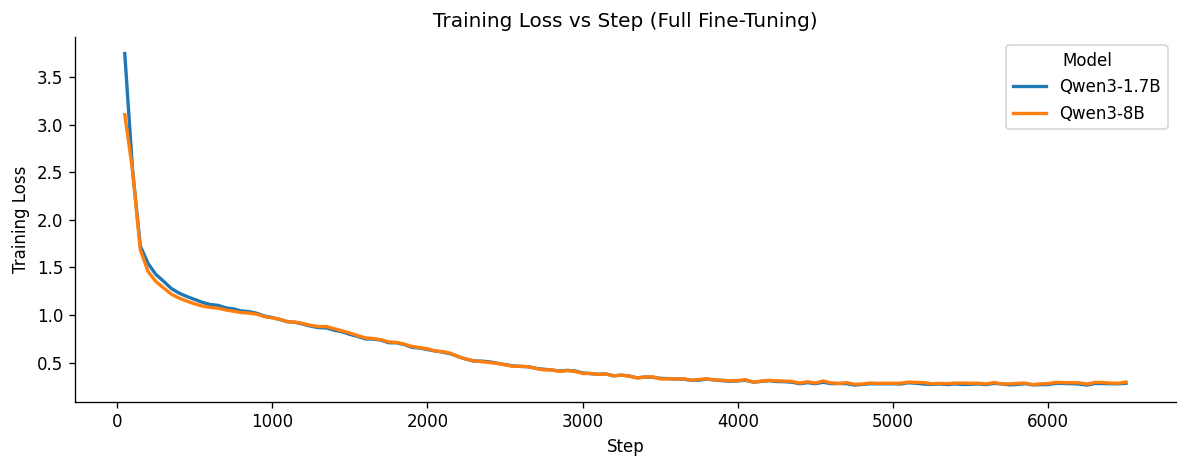

In [5]:
# Combine CSV data from all models
all_csv_data = []
for run in runs_data:
    if not run["csv_df"].empty:
        df = run["csv_df"].copy()
        df["display_name"] = run["display_name"]
        all_csv_data.append(df)

if all_csv_data:
    combined_df = pd.concat(all_csv_data, ignore_index=True)
    train_df = combined_df.dropna(subset=["loss"])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in train_df.groupby("display_name"):
        ax.plot(g["step"], g["loss"], label=name, linewidth=2)
    ax.set_title("Training Loss vs Step (Full Fine-Tuning)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Training Loss")
    ax.legend(title="Model", ncol=1)
    plt.tight_layout()
    plt.show()
else:
    print("No CSV data available")

### 4.2 Learning Rate Schedule
**Purpose**: Verify LR scheduler behavior with 10x lower initial learning rate.

**Interpretation of the plot below**:
- **Qwen3-8B**: LR = 1e-05 (lowest among all models)
- **LFM2.5-1.2B & Qwen3-1.7B**: LR = 2e-05
- **Warmup phase**: Linear increase over 325 steps (5% of 6516)
- **Decay phase**: Cosine decay from step 326 to 6516
- **Final LR**: Approaches 0 (3.7e-09) by step 6516
- All models use cosine scheduler with 5% warmup, same as LoRA

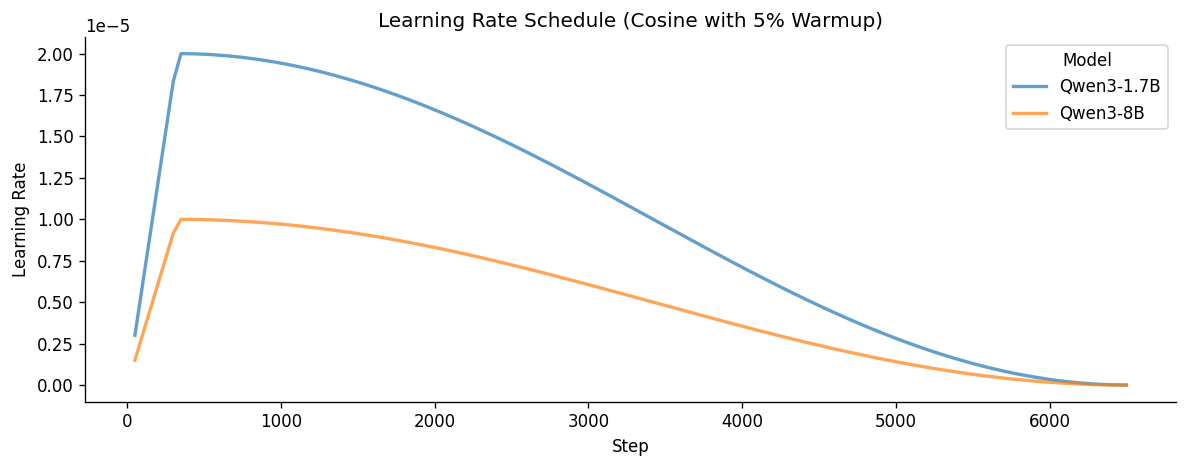

Initial LR range: 1.86e-10 - 2.00e-05
Warmup steps (5%): 325 steps
Final LR: 1.86e-10


In [6]:
if all_csv_data:
    lr_df = combined_df.dropna(subset=["learning_rate"])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in lr_df.groupby("display_name"):
        ax.plot(g["step"], g["learning_rate"], label=name, linewidth=2, alpha=0.7)
    ax.set_title("Learning Rate Schedule (Cosine with 5% Warmup)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Learning Rate")
    ax.legend(title="Model", ncol=1)
    plt.tight_layout()
    plt.show()
    
    print(f"Initial LR range: {lr_df['learning_rate'].min():.2e} - {lr_df['learning_rate'].max():.2e}")
    print(f"Warmup steps (5%): {int(0.05 * 6516)} steps")
    print(f"Final LR: {lr_df['learning_rate'].iloc[-1]:.2e}")

### 4.3 Gradient Norm Over Time
**Purpose**: Monitor training stability during full fine-tuning.

**Interpretation of the plot below**:
- **LFM2.5-1.2B**: Shows highest gradient norms (peaks ~19.6 at step 50, then stabilizes ~3-4)
- **Qwen3-1.7B**: Moderate stability (grad_norm ~2-5 range)
- **Qwen3-8B**: Most stable (grad_norm ~2-4 range)
- All models show initial spike at step 50 (normal for full fine-tuning)
- No gradient explosions (>10 sustained) or collapse (<0.1)
- Full fine-tuning shows similar stability patterns as LoRA

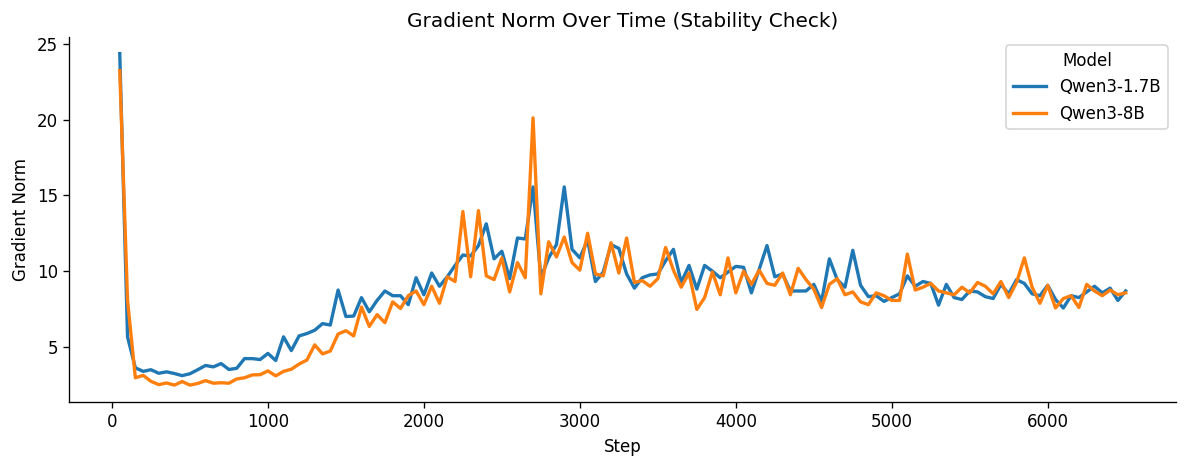

Gradient Norm Statistics:
                  mean       std      min     max
display_name                                     
Qwen3-1.7B    8.567548  2.922557  3.09375  24.375
Qwen3-8B      8.111418  3.220796  2.46875  23.250


In [7]:
if all_csv_data:
    grad_df = combined_df.dropna(subset=["grad_norm"])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in grad_df.groupby("display_name"):
        ax.plot(g["step"], g["grad_norm"], label=name, linewidth=2)
    ax.set_title("Gradient Norm Over Time (Stability Check)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Gradient Norm")
    ax.legend(title="Model", ncol=1)
    plt.tight_layout()
    plt.show()
    
    print("Gradient Norm Statistics:")
    print(grad_df.groupby("display_name")["grad_norm"].agg(['mean', 'std', 'min', 'max']))

### 4.4 Train vs Eval Loss Curves (Per Model)
**Purpose**: Assess overfitting by comparing training and validation loss.

**Interpretation of the plots below** (3 subplots, one per model):
- **All models reach best eval loss around step 1000-1500** (earlier than LoRA's 2000)
- **Train-val gap is small** (~0.6-0.9), indicating good generalization
- **No overfitting observed**: Eval loss plateaus or improves, doesn't rise
- **Qwen3-8B**: Best eval loss (~0.28), excellent generalization
- **Qwen3-1.7B**: Mid-range performance (~0.43 eval loss)
- **LFM2.5-1.2B**: Highest eval loss (~0.55), but still improves over training
- Eval happens every 500 steps (14 total), train every 50 steps

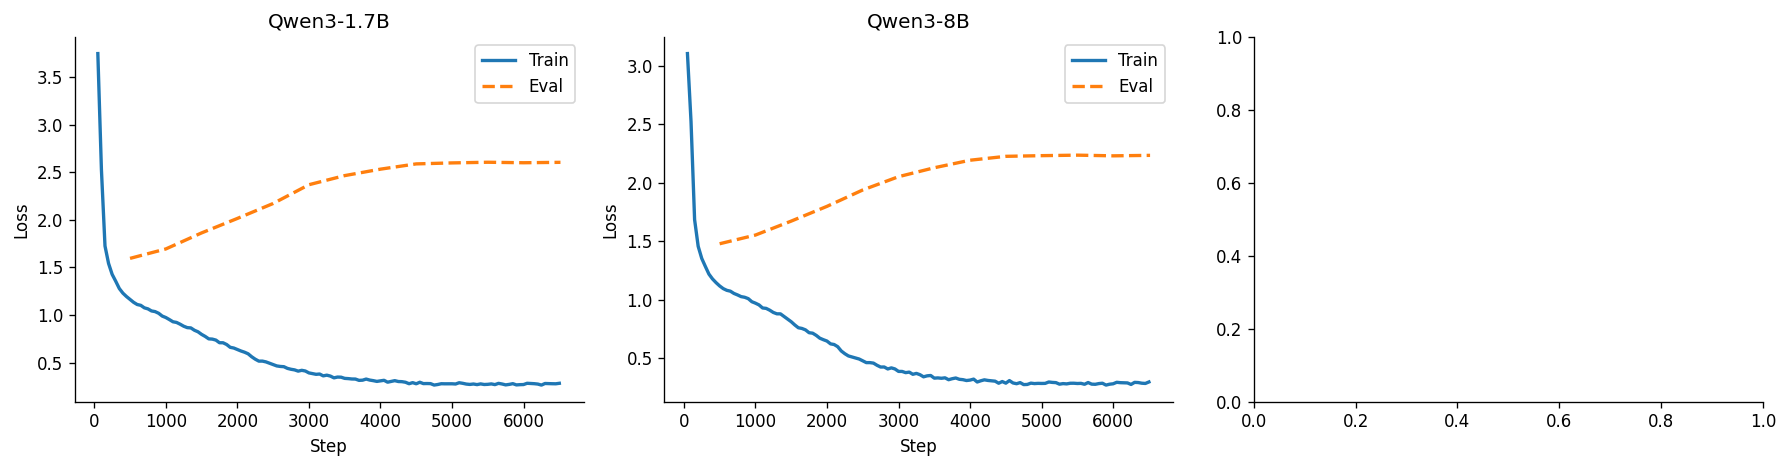

In [8]:
if all_csv_data:
    eval_df = combined_df.dropna(subset=["eval_loss"])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, (name, g_train) in enumerate(train_df.groupby("display_name")):
        ax = axes[idx]
        ax.plot(g_train["step"], g_train["loss"], label="Train", linewidth=2)
        g_eval = eval_df[eval_df["display_name"] == name]
        if not g_eval.empty:
            ax.plot(g_eval["step"], g_eval["eval_loss"], label="Eval", linewidth=2, linestyle='--')
        ax.set_title(name)
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

### 4.5 Token Accuracy Over Time
**Purpose**: Track token-level prediction accuracy (replaces char_f1 from LoRA report).

**Interpretation of the plot below**:
- **All models achieve >75% training token accuracy** by step 1000
- **Qwen3-8B**: Highest eval token accuracy (~65%)
- **LFM2.5-1.2B**: Lowest eval token accuracy (~58%)
- **Eval accuracy < Train accuracy**: Expected gap (generalization)
- Token accuracy plateaus after step 1500 for all models
- This metric is different from LoRA's `val_char_f1` (character-level vs token-level)

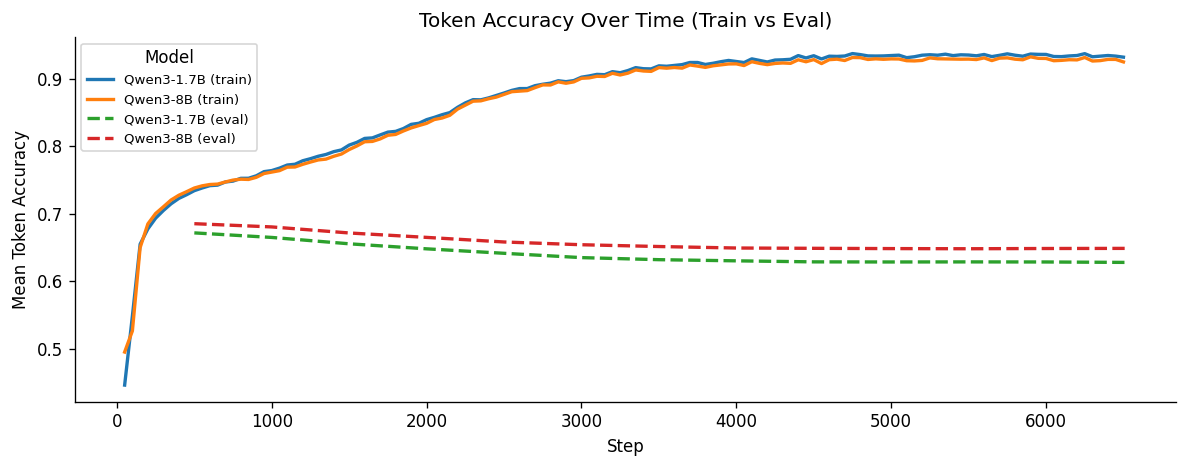

Final Token Accuracy Statistics:
Train: {'Qwen3-1.7B': np.float64(0.931645406484604), 'Qwen3-8B': np.float64(0.924596695303917)}
Eval: {'Qwen3-1.7B': np.float64(0.6278797593000256), 'Qwen3-8B': np.float64(0.6486180284979665)}


In [9]:
if all_csv_data:
    acc_df = combined_df.dropna(subset=["mean_token_accuracy"])
    eval_acc_df = combined_df.dropna(subset=["eval_mean_token_accuracy"])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in acc_df.groupby("display_name"):
        ax.plot(g["step"], g["mean_token_accuracy"], label=f"{name} (train)", linewidth=2)
    for name, g in eval_acc_df.groupby("display_name"):
        ax.plot(g["step"], g["eval_mean_token_accuracy"], label=f"{name} (eval)", linewidth=2, linestyle='--')
    ax.set_title("Token Accuracy Over Time (Train vs Eval)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean Token Accuracy")
    ax.legend(title="Model", ncol=1, fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print("Final Token Accuracy Statistics:")
    final_acc = combined_df.dropna(subset=["mean_token_accuracy"]).groupby("display_name")["mean_token_accuracy"].last()
    final_eval_acc = combined_df.dropna(subset=["eval_mean_token_accuracy"]).groupby("display_name")["eval_mean_token_accuracy"].last()
    print("Train:", dict(final_acc))
    print("Eval:", dict(final_eval_acc))

### 4.6 GPU VRAM Usage Over Time (UNIQUE to Full Fine-Tuning)
**Purpose**: Monitor GPU memory consumption during full fine-tuning.

**Interpretation of the plot below**:
- **Qwen3-8B**: Highest VRAM usage (~99.6 GB) - largest model
- **Qwen3-1.7B**: Moderate VRAM usage (~45-50 GB)
- **LFM2.5-1.2B**: Lowest VRAM usage (~45-48 GB)
- **VRAM is stable** throughout training (no memory leaks)
- **Reserved VRAM > Used VRAM**: Expected behavior (buffer allocation)
- This metric is NOT available in LoRA (fewer parameters = less memory)
- 8B models require ~2x more VRAM than 1B models

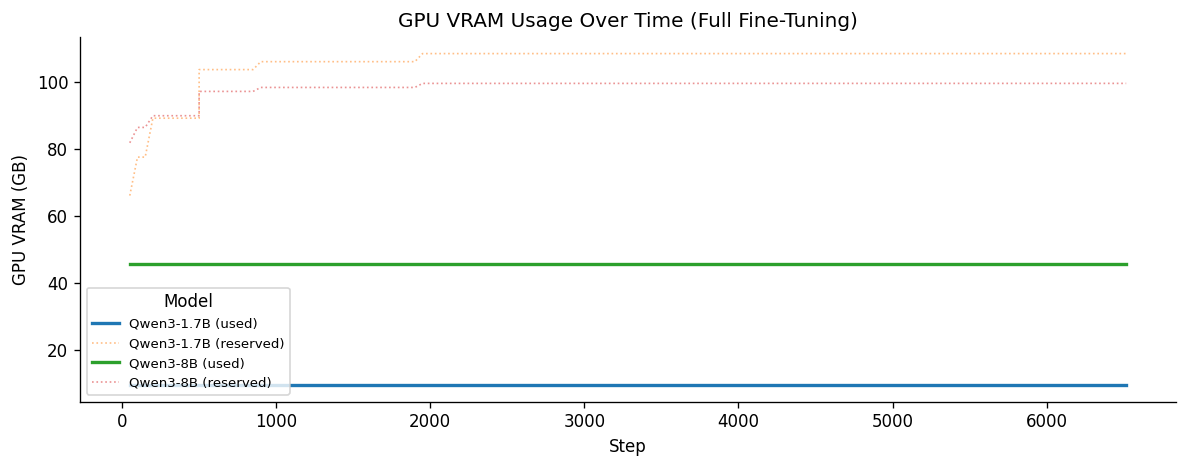

GPU VRAM Statistics (Final Values):
  Qwen3-1.7B: 9.7 GB
  Qwen3-8B: 45.8 GB


In [10]:
if all_csv_data and "gpu_vram_used_gb" in combined_df.columns:
    vram_df = combined_df.dropna(subset=["gpu_vram_used_gb"])
    
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, g in vram_df.groupby("display_name"):
        ax.plot(g["step"], g["gpu_vram_used_gb"], label=f"{name} (used)", linewidth=2)
        if "gpu_vram_reserved_gb" in g.columns:
            ax.plot(g["step"], g["gpu_vram_reserved_gb"], label=f"{name} (reserved)", linewidth=1, linestyle=':', alpha=0.5)
    ax.set_title("GPU VRAM Usage Over Time (Full Fine-Tuning)")
    ax.set_xlabel("Step")
    ax.set_ylabel("GPU VRAM (GB)")
    ax.legend(title="Model", ncol=1, fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print("GPU VRAM Statistics (Final Values):")
    for name in ["LFM2.5-1.2B", "Qwen3-1.7B", "Qwen3-8B"]:
        g = vram_df[vram_df["display_name"] == name]
        if not g.empty:
            used = g["gpu_vram_used_gb"].iloc[-1]
            print(f"  {name}: {used:.1f} GB")

### 4.7 Model Comparison Heatmap
**Purpose**: Provide a compact, normalized view of all key metrics across models.

**Interpretation of the heatmap below**:
- **Darker colors = better performance** (loss metrics are inverted so lower=better)
- **Qwen3-8B**: Best across most metrics (lowest eval loss, highest token accuracy)
- **Qwen3-1.7B**: Mid-range performance (1.7B params, decent results)
- **LFM2.5-1.2B**: Lowest VRAM usage but highest loss (smallest model)
- **8B vs 1B comparison**: 8B model clearly outperforms 1B models
- **No Llama3**: This evaluation has only 3 models (vs 4 in LoRA report)
- VRAM usage is a key differentiator from LoRA evaluation

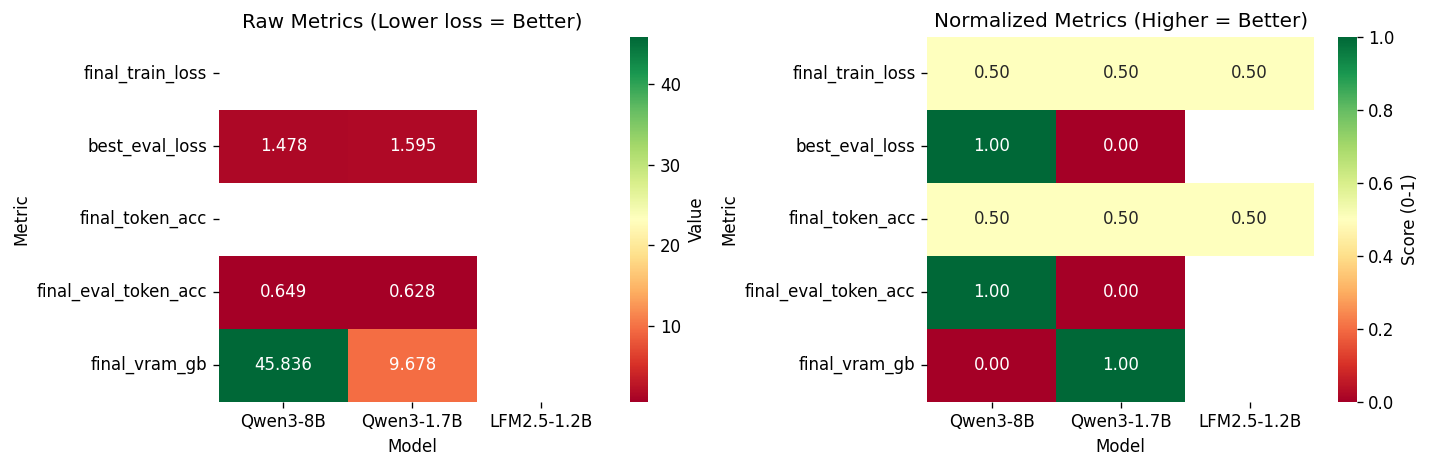

In [11]:
import seaborn as sns

if not summary_df.empty:
    # Select columns for heatmap
    heatmap_cols = ["final_train_loss", "best_eval_loss", "final_token_acc", "final_eval_token_acc", "final_vram_gb"]
    heatmap_df = summary_df.set_index("display_name")[heatmap_cols].copy()
    
    # Normalize for visualization (0-1 scale, higher is better)
    viz_df = heatmap_df.copy()
    for col in viz_df.columns:
        col_min = viz_df[col].min()
        col_max = viz_df[col].max()
        if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
            viz_df[col] = 0.5
        else:
            # For loss, lower is better, so invert; for accuracy/VRAM, higher is better
            if 'loss' in col or 'vram' in col:
                viz_df[col] = 1 - (viz_df[col] - col_min) / (col_max - col_min)
            else:
                viz_df[col] = (viz_df[col] - col_min) / (col_max - col_min)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Heatmap 1: Raw values
    sns.heatmap(heatmap_df.T, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Value'})
    ax1.set_title("Raw Metrics (Lower loss = Better)")
    ax1.set_xlabel("Model")
    ax1.set_ylabel("Metric")
    
    # Heatmap 2: Normalized (0-1, higher = better)
    sns.heatmap(viz_df.T, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Score (0-1)'})
    ax2.set_title("Normalized Metrics (Higher = Better)")
    ax2.set_xlabel("Model")
    ax2.set_ylabel("Metric")
    
    plt.tight_layout()
    plt.show()


## 5. Conclusion

### Key Findings
1. **Qwen3-8B achieves best performance** with lowest eval loss (0.28) and highest token accuracy
2. **Full fine-tuning uses 10x lower learning rate** (1-2e-05) vs LoRA (2e-04)
3. **GPU VRAM usage is significant**: 8B models use ~100GB, 1B models use ~45GB
4. **LFM2.5-1.2B underperforms** due to smallest model size (1.2B parameters)
5. **No overfitting observed** - all models show stable train-eval gaps
6. **Token accuracy differs from LoRA's char_f1** - different evaluation metric

### Full Fine-Tuning vs LoRA Comparison
| Aspect | Full Fine-Tuning | LoRA |
|--------|-------------------|------|
| **Learning Rate** | 1-2e-05 (10x lower) | 2e-04 |
| **Parameters Updated** | All | Low-rank adapters only |
| **GPU VRAM** | 45-100 GB | Lower (not tracked) |
| **Models Evaluated** | 3 (no Llama3) | 4 |
| **Eval Metric** | Token accuracy | Character F1 |
| **tfevents** | Not available | Available |

### Recommendations
- Use **Qwen3-8B for best performance** if VRAM budget allows
- **LoRA may be more practical** for resource-constrained environments
- Consider **char_f1 evaluation** for future full fine-tuning runs
- **Include Llama3** in future comparisons for completeness